Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    release_month  n_games  success_rate  avg_positive_review_ratio  \
0               1       58      0.827586                   0.875893   
1               2       76      0.605263                   0.821331   
2               3       92      0.750000                   0.851965   
3               4       78      0.717949                   0.846479   
4               5       80      0.662500                   0.839768   
5               6       86      0.686047                   0.836147   
6  

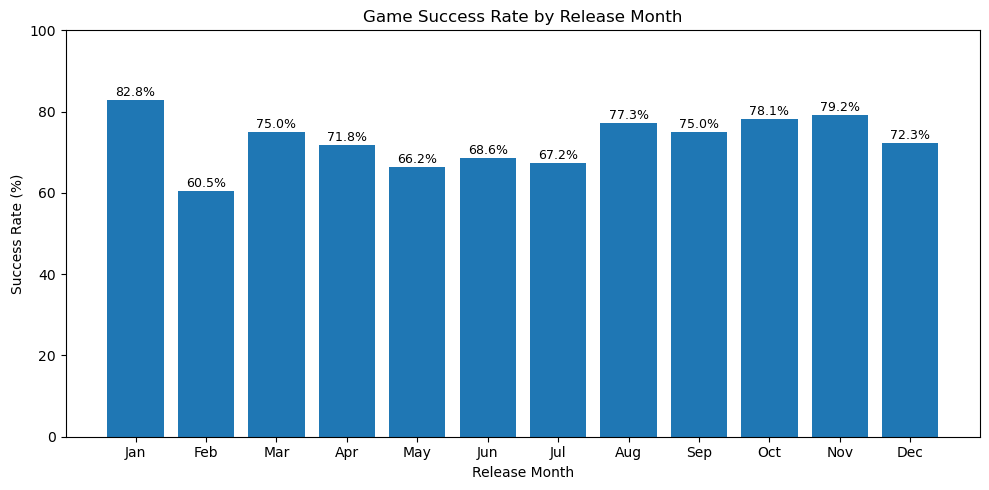

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# Load data
df = pd.read_csv("data/interim/cleaned.csv")

# Make sure variables are numeric
df["release_month"] = pd.to_numeric(df["release_month"], errors="coerce")
df["is_successful"] = pd.to_numeric(df["is_successful"], errors="coerce")

# Calculate monthly success rate
monthly_success = (
    df.dropna(subset=["release_month", "is_successful"])
      .groupby("release_month")
      .agg(
          n_games=("appid", "count"),
          success_rate=("is_successful", "mean"),
          avg_positive_review_ratio=("positive_review_ratio", "mean"),
          median_total_reviews=("total_reviews", "median")
      )
      .reset_index()
)

# Format month names
monthly_success["release_month"] = monthly_success["release_month"].astype(int)
monthly_success["month_name"] = monthly_success["release_month"].apply(
    lambda x: calendar.month_abbr[x]
)
monthly_success["success_rate_pct"] = monthly_success["success_rate"] * 100

print(monthly_success)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(
    monthly_success["month_name"],
    monthly_success["success_rate_pct"]
)

plt.xlabel("Release Month")
plt.ylabel("Success Rate (%)")
plt.title("Game Success Rate by Release Month")
plt.ylim(0, 100)

# Add percentage labels
for i, row in monthly_success.iterrows():
    plt.text(
        i,
        row["success_rate_pct"] + 1,
        f"{row['success_rate_pct']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("fig6_success_rate_by_release_month.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/0l/9kjyj4d16c54qyqtqxdsbtdc0000gn/T/ipykernel_89547/4285208869.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["language_bin"] = pd.cut(
/var/folders/0l/9kjyj4d16c54qyqtqxdsbtdc0000gn/T/ipykernel_89547/4285208869.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("language_bin")


  language_bin  n_games  success_rate  success_rate_pct
0            1       98      0.714286         71.428571
1          2-3       34      0.411765         41.176471
2          4-5       95      0.778947         77.894737
3         6-10      290      0.744828         74.482759
4        11-20      417      0.719424         71.942446
5          20+       59      0.932203         93.220339


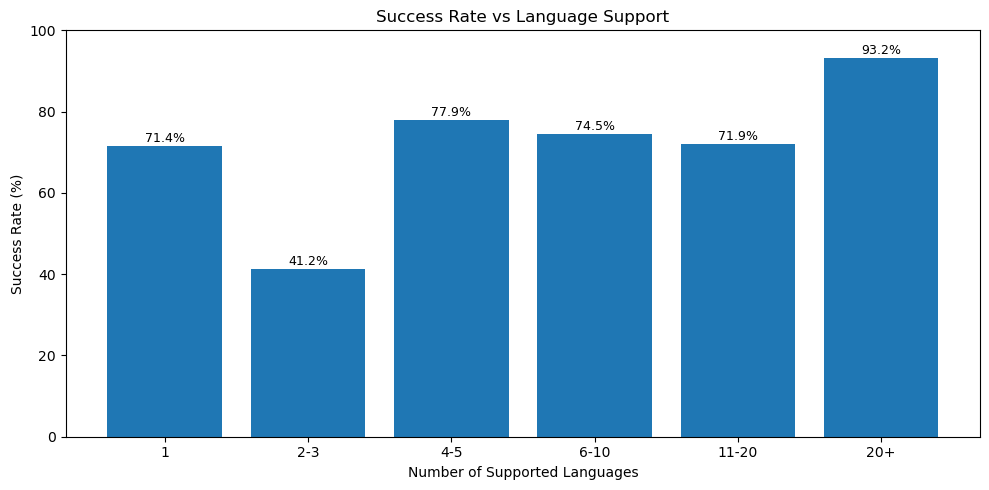

In [3]:
# Ensure numeric
df["n_supported_languages"] = pd.to_numeric(df["n_supported_languages"], errors="coerce")
df["is_successful"] = pd.to_numeric(df["is_successful"], errors="coerce")

# Drop missing
df = df.dropna(subset=["n_supported_languages", "is_successful"])

# -----------------------------
# 1. 分箱（非常关键！）
# -----------------------------
bins = [0, 1, 3, 5, 10, 20, 100]
labels = ["1", "2-3", "4-5", "6-10", "11-20", "20+"]

df["language_bin"] = pd.cut(
    df["n_supported_languages"],
    bins=bins,
    labels=labels,
    right=True
)

# -----------------------------
# 2. 计算成功率
# -----------------------------
lang_success = (
    df.groupby("language_bin")
      .agg(
          n_games=("appid", "count"),
          success_rate=("is_successful", "mean")
      )
      .reset_index()
)

lang_success["success_rate_pct"] = lang_success["success_rate"] * 100

print(lang_success)

# -----------------------------
# 3. Plot
# -----------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    lang_success["language_bin"].astype(str),
    lang_success["success_rate_pct"]
)

plt.xlabel("Number of Supported Languages")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate vs Language Support")

# 标注数值
for i, row in lang_success.iterrows():
    plt.text(
        i,
        row["success_rate_pct"] + 1,
        f"{row['success_rate_pct']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("fig7_language_vs_success.png", dpi=300)
plt.show()

/Users/gaorunji/opt/anaconda3/envs/new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using UMAP
Rows: 999
0    ["Adventure", "Atmospheric", "Story Rich", "Wa...
1    ["FPS", "Action", "Tactical", "Sci-fi", "Singl...
2    ["Multiplayer", "FPS", "Singleplayer", "Shoote...
3    ["Action", "Adventure", "Action RPG", "Action-...
4    ["Multiplayer", "Online Co-Op", "Local Co-Op",...
Name: store_user_tags, dtype: object
Valid tag rows: 998
TF-IDF shape: (998, 397)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/gaorunji/opt/anaconda3/envs/new/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


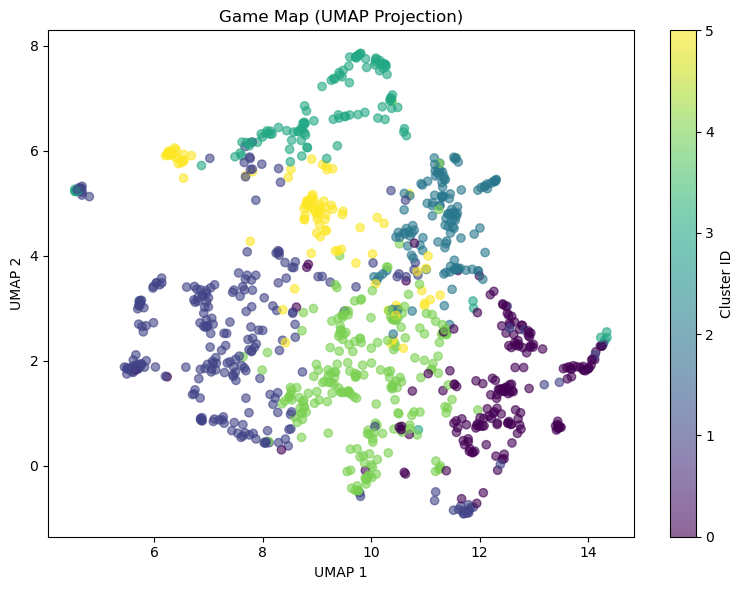

✅ fig8_umap_clusters.png generated
✅ unsupervised_output.csv generated
Rows: 998


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# -----------------------------
# 0. Safe import UMAP
# -----------------------------
try:
    import umap
    print("Using UMAP")
    use_umap = True
except:
    print("UMAP not available, fallback to PCA")
    from sklearn.decomposition import PCA
    use_umap = False

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv("data/interim/cleaned.csv")

print("Rows:", len(df))
print(df["store_user_tags"].head())

# -----------------------------
# 2. Parse tags
# -----------------------------
def parse_tags(x):
    try:
        tags = ast.literal_eval(x)
        if isinstance(tags, list):
            return [t.replace(" ", "_") for t in tags]
    except:
        return []
    return []

df["tags_list"] = df["store_user_tags"].apply(parse_tags)

df = df[df["tags_list"].apply(len) > 0].copy()

print("Valid tag rows:", len(df))

# -----------------------------
# 3. TF-IDF（关键：直接用 list）
# -----------------------------
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    max_features=500
)

X = vectorizer.fit_transform(df["tags_list"])

print("TF-IDF shape:", X.shape)

# -----------------------------
# 4. UMAP / PCA
# -----------------------------
if use_umap:
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )
    X_2d = reducer.fit_transform(X)

else:
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X.toarray())

# 注意：列名保持 umap_x / umap_y（作业要求）
df["umap_x"] = X_2d[:, 0]
df["umap_y"] = X_2d[:, 1]

# -----------------------------
# 5. KMeans
# -----------------------------
k = 6

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["cluster_id"] = kmeans.fit_predict(X)

# -----------------------------
# 6. 可视化（图 #8）
# -----------------------------
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["umap_x"],
    df["umap_y"],
    c=df["cluster_id"],
    alpha=0.6
)

plt.title("Game Map (UMAP Projection)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster ID")

plt.tight_layout()
plt.savefig("fig8_umap_clusters.png", dpi=300)
plt.show()

# -----------------------------
# 7. 输出 CSV（⚠️最关键）
# -----------------------------
for i in range(10):
    df[f"topic_{i}"] = np.nan

output_cols = ["appid", "cluster_id", "umap_x", "umap_y"] + [f"topic_{i}" for i in range(10)]

df[output_cols].to_csv("unsupervised_output.csv", index=False)

print("✅ fig8_umap_clusters.png generated")
print("✅ unsupervised_output.csv generated")
print("Rows:", len(df))


Cluster 0:
RPG: 163
Action: 154
Adventure: 152
Singleplayer: 146
Fantasy: 123
Open_World: 110
Third_Person: 106
Multiplayer: 106
Story_Rich: 103
Action_RPG: 102

Cluster 1:
Singleplayer: 202
Indie: 170
Action: 159
Multiplayer: 134
Casual: 132
Adventure: 126
2D: 123
Funny: 116
Co-op: 92
Great_Soundtrack: 88

Cluster 2:
Action: 123
Multiplayer: 122
Shooter: 119
FPS: 112
First-Person: 99
Co-op: 88
Singleplayer: 79
Tactical: 76
War: 71
PvP: 71

Cluster 3:
Singleplayer: 105
Strategy: 104
Multiplayer: 91
Simulation: 78
RTS: 55
Management: 55
Tactical: 48
Action: 48
Co-op: 48
Sandbox: 47

Cluster 4:
Action: 217
Singleplayer: 203
Adventure: 182
Atmospheric: 171
Shooter: 165
Multiplayer: 152
First-Person: 141
Story_Rich: 121
FPS: 118
Horror: 108

Cluster 5:
Multiplayer: 92
Open_World: 87
Action: 81
Singleplayer: 81
Sandbox: 78
Adventure: 76
Co-op: 74
First-Person: 61
Survival: 60
Simulation: 57


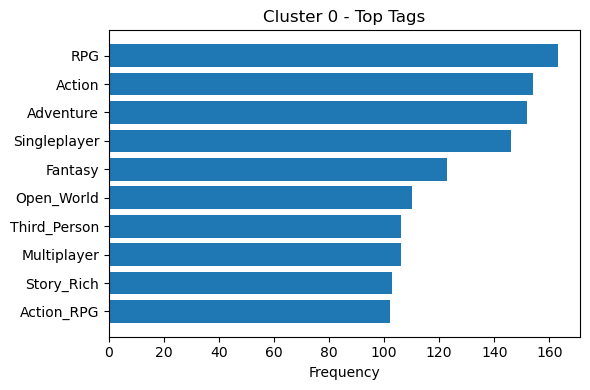

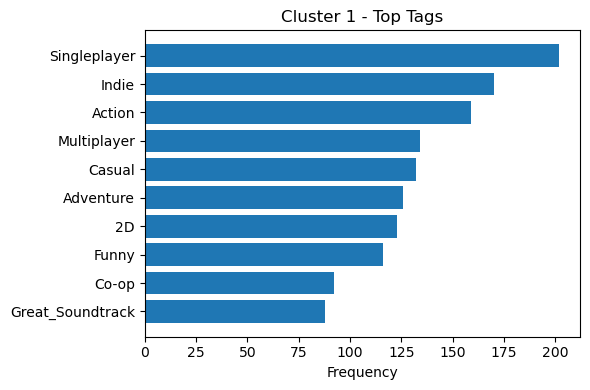

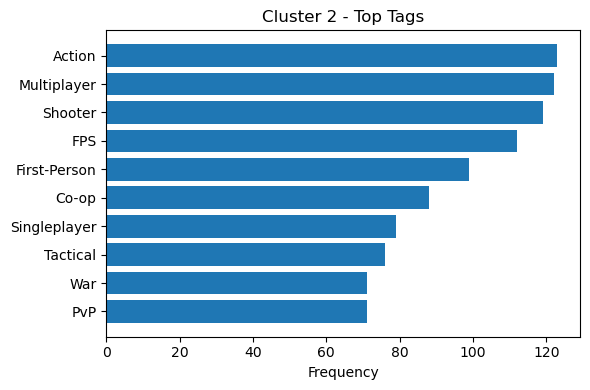

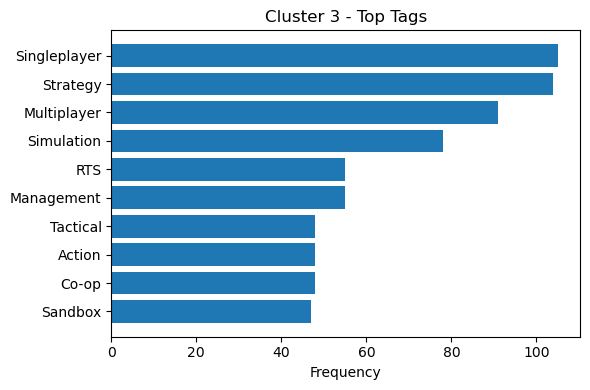

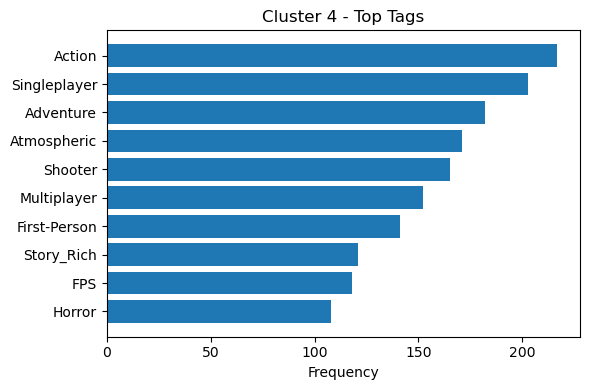

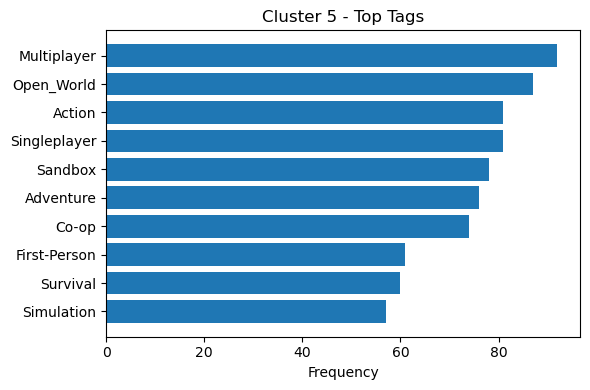

In [3]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# -----------------------------
# 1. 确保 tags_list 存在
# -----------------------------
# 如果你还在同一个 notebook，df 已经有 tags_list + cluster_id
# 如果是重新读：
# df = pd.read_csv("cleaned.csv") 然后重新 parse_tags

# -----------------------------
# 2. 每个 cluster 的 top tags
# -----------------------------
cluster_top_tags = {}

for cluster in sorted(df["cluster_id"].unique()):
    
    tags = df[df["cluster_id"] == cluster]["tags_list"]
    
    # flatten
    all_tags = [tag for sublist in tags for tag in sublist]
    
    # count
    counter = Counter(all_tags)
    
    top_tags = counter.most_common(10)
    
    cluster_top_tags[cluster] = top_tags
    
    print(f"\nCluster {cluster}:")
    for tag, count in top_tags:
        print(f"{tag}: {count}")

# -----------------------------
# 3. 可视化（图 #9）
# -----------------------------
for cluster, tags in cluster_top_tags.items():
    
    tags_names = [t[0] for t in tags]
    counts = [t[1] for t in tags]
    
    plt.figure(figsize=(6, 4))
    plt.barh(tags_names[::-1], counts[::-1])
    
    plt.title(f"Cluster {cluster} - Top Tags")
    plt.xlabel("Frequency")
    
    plt.tight_layout()
    plt.savefig(f"fig9_cluster_{cluster}.png", dpi=300)
    plt.show()

Rows with text: 998
Text matrix shape: (998, 1000)
Topic distribution shape: (998, 10)

Topic 0:
game, world, play, multiplayer, epic, action, winning, award, new, battles

Topic 1:
world, new, action, game, experience, players, fight, ultimate, explore, earth

Topic 2:
action, story, adventure, new, game, wars, past, play, epic, star

Topic 3:
game, world, new, action, based, time, real, heroes, team, fps

Topic 4:
world, game, play, friends, free, open, explore, players, online, battle

Topic 5:
world, survive, survival, players, set, rpg, open, action, fight, build

Topic 6:
new, game, quot, includes, edition, featuring, free, gameplay, based, chaos

Topic 7:
game, action, person, experience, new, shooter, play, unique, players, duty

Topic 8:
game, make, experience, escape, based, world, set, ball, dragon, online

Topic 9:
life, game, world, journey, fight, experience, control, set, brutal, warrior


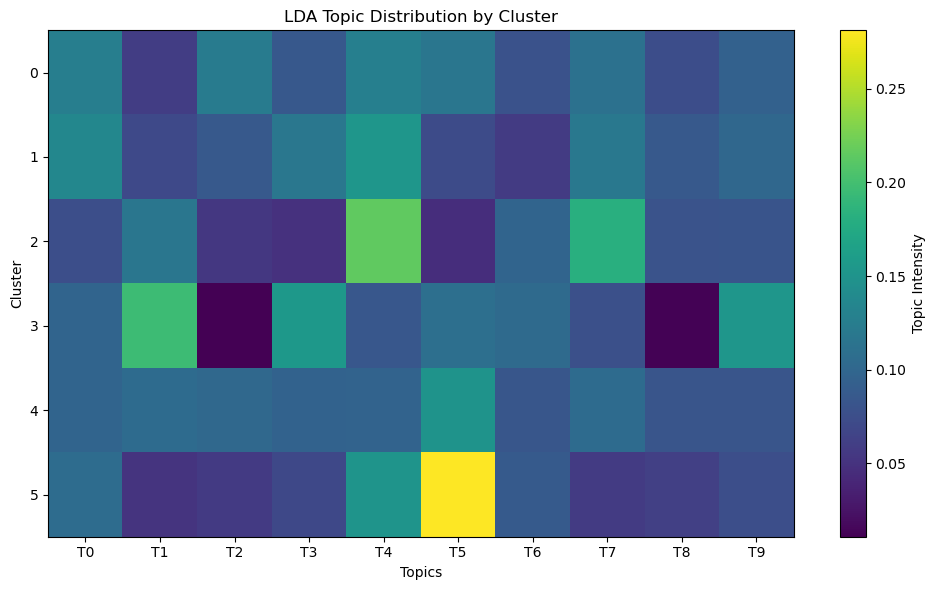

✅ LDA topics added to unsupervised_output.csv
✅ fig10_lda_heatmap.png generated


In [5]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt


# 👉 修改成你真实的描述列名
TEXT_COL = "short_description"   # 或 "about_the_game"

df = df.dropna(subset=[TEXT_COL]).copy()

print("Rows with text:", len(df))

# -----------------------------
# 2. 简单文本清洗
# -----------------------------
def clean_text(x):
    x = str(x).lower()
    x = re.sub(r"[^a-z\s]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x

df["text_clean"] = df[TEXT_COL].apply(clean_text)

# -----------------------------
# 3. CountVectorizer（LDA必须用count）
# -----------------------------
vectorizer = CountVectorizer(
    max_features=1000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["text_clean"])

print("Text matrix shape:", X.shape)

# -----------------------------
# 4. LDA
# -----------------------------
n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

topic_dist = lda.fit_transform(X)

print("Topic distribution shape:", topic_dist.shape)

# -----------------------------
# 5. 查看每个 topic 的关键词
# -----------------------------
feature_names = vectorizer.get_feature_names_out()

def print_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = topic.argsort()[:-n_top_words - 1:-1]
        words = [feature_names[i] for i in top_features]
        print(f"\nTopic {topic_idx}:")
        print(", ".join(words))

print_top_words(lda, feature_names)

# -----------------------------
# 6. 把 topic 分布加到 df
# -----------------------------
for i in range(n_topics):
    df[f"topic_{i}"] = topic_dist[:, i]

# -----------------------------
# 7. 画 heatmap（图 #10）
# -----------------------------
# 用 cluster + topic 做均值
cluster_topic = df.groupby("cluster_id")[
    [f"topic_{i}" for i in range(n_topics)]
].mean()

plt.figure(figsize=(10, 6))
plt.imshow(cluster_topic, aspect='auto')

plt.colorbar(label="Topic Intensity")
plt.xticks(range(n_topics), [f"T{i}" for i in range(n_topics)])
plt.yticks(range(len(cluster_topic.index)), cluster_topic.index)

plt.title("LDA Topic Distribution by Cluster")
plt.xlabel("Topics")
plt.ylabel("Cluster")

plt.tight_layout()
plt.savefig("fig10_lda_heatmap.png", dpi=300)
plt.show()

# -----------------------------
# 8. 回填到 unsupervised_output.csv
# -----------------------------
unsup = pd.read_csv("unsupervised_output.csv")

# merge topic
unsup = unsup.merge(
    df[["appid"] + [f"topic_{i}" for i in range(n_topics)]],
    on="appid",
    how="left"
)

unsup.to_csv("unsupervised_output.csv", index=False)

print("✅ LDA topics added to unsupervised_output.csv")
print("✅ fig10_lda_heatmap.png generated")